# Aufgabe 6: vollständige Auswertung über 100 Spendersplits

Diese ausgeführte Berichtsfassung verwendet den unveränderten Modell-/Trainingscode aus `06b_cellcnn_mahalanobis_learnable_pooling.ipynb`. Alle Splits 0–99 werden ausgewertet. Dafür werden die lokal vorhandenen, passenden Modelle geladen; ein neues Benchmark-Training startet diese Fassung nicht. Die kleinen eingebauten Smoke-Tests bleiben aktiv.

# Aufgabe 6b: Diagonale Prototypfilter mit lernbarem Poolinganteil

Diese Bonusvariante lernt pro Filter, welche oberen Ränge der Zellantworten beim Pooling stärker gewichtet werden. Sie ist eine eigene Erweiterung von CellCNN; jeder diagonale Prototypfilter besitzt wieder einen lernbaren positiven Radius.

Für standardisierte Markerwerte gilt

$$d_k^2(x)=\operatorname{mean}_j\left[a_{kj}(x_j-c_{kj})^2\right],\qquad h_k(x)=\operatorname{ReLU}(\rho_k-d_k^2(x)),\qquad \rho_k=\operatorname{softplus}(\mathrm{raw\_rho}_k)+\varepsilon.$$

$c_k$ ist das Zentrum bzw. der Prototyp der bevorzugten Zellpopulation. Die positiven, durch Softplus erzeugten und pro Filter auf Mittelwert eins normierten $a_{kj}$ bestimmen die relative Markerskalierung der diagonalen Distanz; sie sind keine kausalen Markerrelevanzen.

Mit einem freien Parameter $\theta_k$ lernt jeder Filter $\alpha_k=\operatorname{sigmoid}(\theta_k)$. Für absteigend sortierte Antworten $h_{(1)k}\geq\dots\geq h_{(N)k}$ verwenden wir

$$q_j=\frac{j-0.5}{N},\qquad m_{jk}=\operatorname{sigmoid}\left(\frac{\alpha_k-q_j}{\tau}\right),\qquad P_k=\frac{\sum_j m_{jk}h_{(j)k}}{\sum_j m_{jk}}.$$

Die feste Temperatur ist $\tau=0.002$ in Einheiten der Zellfraktion. Anfangs gilt $\alpha_k=0.01$: Das startet nahe am Top-1%-Pooling der Baseline, aber wegen der weichen Maske nicht identisch dazu. Kleine Anteile konzentrieren das Pooling auf hohe Antworten, große Anteile machen es mean-artiger. $\alpha_k$ ist ein **weicher Rang-Cutoff**, kein exakter Anteil ausgewählter Zellen. Bei festem $\tau$ bleibt auch für $\alpha_k\to0$ eine Glättung über mehrere Zellen bestehen; echtes Max-Pooling wird nicht erreicht.

Der Radius begrenzt die trainierte Zellresponse. Die spätere Half-Max-Schwelle definiert darauf eine Population; Radius, Alpha und Populationsfrequenz erfüllen unterschiedliche Rollen.

Der bestehende lineare Output-Layer verarbeitet $P$. Gegenüber 06a unterscheiden sich Filterform, Zellantwort, Pooling und der bereits im alten 06b geänderte L2-Umfang. Eine AUC-Differenz kann deshalb nicht allein dem Lernen von $\alpha$ zugeschrieben werden. Die unveränderten Baseline-Artefakte aus 06a werden ausschließlich gelesen.

In [1]:
from pathlib import Path
import copy
import csv
import hashlib
import json
import os
import sys
import time
import warnings
from importlib.metadata import version

# Vor der ersten CUDA-Operation: deterministische cuBLAS-Ausführung.
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import flowkit as fk
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from IPython.display import display

BONUS_SPLIT_IDS = list(range(100))
SPLIT_IDS = BONUS_SPLIT_IDS
GATE, RUN_MODE, GATE_SUFFIX = "gated_alive", "full", "_alive"
COFACTOR, TOP_FRACTION = 5.0, 0.01
LEARNING_RATE, L2_COEFFICIENT = 0.01, 1e-4
GEOMETRY_COEFFICIENT = 1e-3  # Ausdrücklich vorläufiger Experimentwert; keine Hyperparametersuche.
if not np.isfinite(GEOMETRY_COEFFICIENT) or GEOMETRY_COEFFICIENT < 0:
    raise ValueError("GEOMETRY_COEFFICIENT muss endlich und nichtnegativ sein.")
TRAINING_CELLS_PER_INPUT, TRAINING_INPUTS_PER_DONOR = 3000, 200
PREDICTION_CELLS_PER_INPUT, PREDICTION_INPUTS_PER_DONOR = 20000, 5
SCALER_CELLS_PER_DONOR = 20000
FILTER_COUNTS, BATCH_SIZE = [3, 4, 5], 128
MAX_EPOCHS, EARLY_STOPPING_PATIENCE = 100, 5
EVALUATION_CELLS_PER_DONOR, EVALUATION_SEED = 20000, 63000
EXPECTED_EVENT_COUNTS = {"gated_alive": 3438750}

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "NK_cell_dataset").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_ROOT = PROJECT_ROOT / "NK_cell_dataset/NK_cell_dataset"
FCS_DIR = DATA_ROOT / "NK_cell_dataset" / GATE
LABELS_PATH, MARKERS_PATH = DATA_ROOT / "NK_fcs_samples_with_labels.csv", DATA_ROOT / "NK_markers.csv"
TABLES = PROJECT_ROOT / "results/tables"
SPLITS_PATH = TABLES / "task4_donor_splits.csv"
sys.path.insert(0, str(PROJECT_ROOT))
from src.task4_artifacts import make_run_config, file_digest, validate_prediction_splits, validate_parameter_table
from src.task5_interpretation import SavedCellCNN, restore_scaler

torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Gerät: {DEVICE}; PyTorch: {torch.__version__}; Bonus-Splits: {BONUS_SPLIT_IDS}")
# Vollständige Berichtsauswertung: dieselben bereits geprüften Modellartefakte.
os.environ["TASK6_RUN_TRAINING"] = "0"
os.environ["TASK6_SPLIT_LIMIT"] = "0"
os.environ["TASK6_HARD_TABLES"] = str(TABLES)


Gerät: cuda; PyTorch: 2.14.0+cu130; Bonus-Splits: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]


In [2]:
# Zweck: Alle Spenderdaten transformiert, aber weiterhin spenderweise getrennt laden.
with MARKERS_PATH.open(newline="", encoding="utf-8-sig") as stream:
    markers = next(csv.reader(stream))

label_table = pd.read_csv(LABELS_PATH)
label_table["donor_id"] = label_table["fcs_filename"].str.replace(
    r"_NK\.fcs$", "", regex=True
)
label_table["label"] = label_table["label"].astype(int)
fcs_paths = sorted(FCS_DIR.glob("*.fcs"))
fcs_table = pd.DataFrame(
    {
        "donor_id": [path.stem.removesuffix(GATE_SUFFIX) for path in fcs_paths],
        "fcs_path": fcs_paths,
    }
)
sample_table = (
    label_table[["donor_id", "label"]]
    .merge(fcs_table, on="donor_id", validate="one_to_one")
    .sort_values("donor_id")
    .reset_index(drop=True)
)
donor_splits = pd.read_csv(SPLITS_PATH)

assert len(markers) == 37
assert len(fcs_paths) == 20
assert len(sample_table) == 20
assert set(SPLIT_IDS).issubset(set(donor_splits["split_id"]))
split_labels = donor_splits[["donor_id", "label"]].drop_duplicates()
assert split_labels.merge(
    sample_table[["donor_id", "label"]],
    on=["donor_id", "label"],
    validate="one_to_one",
).shape[0] == len(sample_table)

def load_transformed_fcs(path: Path) -> np.ndarray:
    """Eine FCS-Datei read-only als ArcSinh-transformierte Markermatrix laden."""
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore", message=r"FCS file .* reported incorrect data offset.*"
        )
        sample = fk.Sample(str(path), ignore_offset_error=True)
    frame = sample.as_dataframe(source="raw")
    short_names = pd.Index(sample.pns_labels, name="marker")
    if not short_names.is_unique:
        raise ValueError(f"Doppelte FCS-Kurznamen in {path.name}.")
    frame.columns = short_names
    missing = [marker for marker in markers if marker not in frame.columns]
    if missing:
        raise ValueError(f"Fehlende Marker in {path.name}: {missing}")
    values = frame.loc[:, markers].to_numpy(dtype=np.float32, copy=True)
    values = np.arcsinh(values / COFACTOR).astype(np.float32, copy=False)
    if not np.isfinite(values).all():
        raise ValueError(f"Nicht-endliche Werte in {path.name}.")
    return values

# Die getrennte Ablage verhindert ein versehentliches Aufteilen eines Spenders.
data_by_donor = {
    row.donor_id: load_transformed_fcs(row.fcs_path)
    for row in sample_table.itertuples(index=False)
}
label_by_donor = sample_table.set_index("donor_id")["label"].to_dict()
assert sum(map(len, data_by_donor.values())) == EXPECTED_EVENT_COUNTS[GATE]

display(
    pd.DataFrame(
        {
            "donor_id": list(data_by_donor),
            "label": [label_by_donor[x] for x in data_by_donor],
            "cells": [len(data_by_donor[x]) for x in data_by_donor],
        }
    )
)


,donor_id,label,cells
0,a_001,1,82324
1,a_002,1,108267
2,a_003,0,97529
3,a_004,0,140687
4,a_005,1,155335
5,a_006,0,90075
6,a_007,1,104805
7,a_009,0,216632
8,a_010,0,122209
9,a_011,0,258461


In [3]:
# Referenzcode und Eingabedaten prüfen, ohne 04c auszuführen oder Artefakte zu schreiben.
baseline_path = TABLES / "task4_cellcnn_predictions_gated_alive_full.csv"
baseline_config_path = baseline_path.with_suffix(".config.json")
baseline_config = json.loads(baseline_config_path.read_text())
expected_parameters = {
    "method": "cellcnn", "gate": GATE, "run_mode": RUN_MODE,
    "cofactor": COFACTOR, "learning_rate": LEARNING_RATE,
    "l2_coefficient": L2_COEFFICIENT, "top_fraction": TOP_FRACTION,
    "training_cells_per_input": TRAINING_CELLS_PER_INPUT,
    "training_inputs_per_donor": TRAINING_INPUTS_PER_DONOR,
    "prediction_cells_per_input": PREDICTION_CELLS_PER_INPUT,
    "prediction_inputs_per_donor": PREDICTION_INPUTS_PER_DONOR,
    "scaler_cells_per_donor": SCALER_CELLS_PER_DONOR,
    "filter_counts": FILTER_COUNTS, "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS, "patience": EARLY_STOPPING_PATIENCE,
    "threshold": 0.5, "implementation_version": "pytorch_materialized_v1",
    "model_format": "complete_filter_parameters_v1",
}
expected_config = make_run_config(
    baseline_config["parameters"] | expected_parameters,
    [SPLITS_PATH, LABELS_PATH, MARKERS_PATH, *fcs_paths],
    PROJECT_ROOT / "notebooks/04c_cellcnn.ipynb", [4, 6, 8, 10],
)
if baseline_config != expected_config:
    raise ValueError("Baseline-Konfiguration, Referenzcode oder Eingangsdaten passen nicht.")

baseline_predictions = pd.read_csv(baseline_path, float_precision="round_trip")
baseline_filters_path = TABLES / "task4_cellcnn_filters_gated_alive_full.csv"
baseline_filters = pd.read_csv(baseline_filters_path, float_precision="round_trip")
baseline_selection = pd.read_csv(TABLES / "task4_cellcnn_selection_gated_alive_full.csv")
baseline_predictions = baseline_predictions.loc[baseline_predictions.split_id.isin(BONUS_SPLIT_IDS)].copy()
baseline_filters = baseline_filters.loc[baseline_filters.split_id.isin(BONUS_SPLIT_IDS)].copy()
validate_prediction_splits(baseline_predictions, donor_splits)
validate_parameter_table(baseline_filters, baseline_predictions, markers, ["split_id", "filter_id"],
    ["filter_weight", "filter_bias", "output_weight_0", "output_weight_1",
     "output_bias_0", "output_bias_1", "output_weight_contrast", "scaler_mean", "scaler_scale"])
assert set(baseline_predictions.split_id) == set(BONUS_SPLIT_IDS)
for split_id in BONUS_SPLIT_IDS:
    split = donor_splits.loc[donor_splits.split_id.eq(split_id)]
    assert len(split) == 20 and split.donor_id.nunique() == 20
    assert split.outer_partition.eq("test").sum() == 6
    assert split.outer_partition.eq("train").sum() == 14
    assert set(split.loc[split.outer_partition.eq("train"), "inner_fold"]) == {0, 1, 2}
    selection = baseline_selection.loc[baseline_selection.split_id.eq(split_id)]
    assert len(selection) == 9
    assert set(zip(selection.inner_fold, selection.filter_count)) == {(f, k) for f in range(3) for k in FILTER_COUNTS}
    best = selection.sort_values(
        ["validation_accuracy", "validation_roc_auc", "best_validation_loss", "filter_count", "inner_fold"],
        ascending=[False, False, True, True, True]).iloc[0]
    assert selection.selected.sum() == 1 and bool(best.selected)
    filters = baseline_filters.loc[baseline_filters.split_id.eq(split_id)]
    pred = baseline_predictions.loc[baseline_predictions.split_id.eq(split_id)]
    assert filters.inner_fold.eq(best.inner_fold).all() and pred.selected_inner_fold.eq(best.inner_fold).all()
    assert filters.filter_id.nunique() == best.filter_count and pred.filter_count.eq(best.filter_count).all()
    assert np.allclose(filters.output_weight_contrast, filters.output_weight_1 - filters.output_weight_0)
    assert filters.scaler_scale.gt(0).all()
    for frame in [filters, pred]:
        assert frame.gate.eq(GATE).all() and frame.run_mode.eq(RUN_MODE).all()
        assert frame.top_fraction.eq(TOP_FRACTION).all()
    assert pred.score.between(0, 1).all()

# Identische Originalereignisse je Spender, unabhängig von Modell und Split.
evaluation_indices = {
    donor: np.random.default_rng(EVALUATION_SEED + i).choice(
        len(data_by_donor[donor]), min(EVALUATION_CELLS_PER_DONOR, len(data_by_donor[donor])), replace=False)
    for i, donor in enumerate(sorted(data_by_donor))
}
evaluation_config = {
    "baseline_config": baseline_config,
    "baseline_predictions_sha256": file_digest(baseline_path),
    "baseline_filters_sha256": file_digest(baseline_filters_path),
    "split_ids": BONUS_SPLIT_IDS, "evaluation_seed": EVALUATION_SEED,
    "evaluation_cells_per_donor": EVALUATION_CELLS_PER_DONOR,
    "selection": "largest_positive_output_contrast", "baseline_membership": "half_inner_training_maximum",
    "halfmax_zero_rule": "strict_response_greater_than_half_maximum",
    "event_indices_sha256": hashlib.sha256(b"".join(
        evaluation_indices[d].astype("<i8").tobytes() for d in sorted(evaluation_indices))).hexdigest(),
}
print("Baseline-Artefakte, Referenzcode und spenderweise Splits geprüft.")


Baseline-Artefakte, Referenzcode und spenderweise Splits geprüft.


## Modell und unveränderte Trainingsgrundlage

Sampling, Skalierung und Auswahl folgen dem alten 06b; die bestehende Geometriestrafe bleibt unverändert. Die neun Kandidaten je Outer-Split (drei innere Folds × drei Filterzahlen) werden nach Validierungsgenauigkeit, AUC, Verlust und festen Tie-Breakern ausgewählt. Das ausgewählte innere Modell wird direkt getestet, ohne Refit auf allen äußeren Trainingsspendern.

Prototypen werden ausschließlich aus gleich vielen Zellen je innerem Trainingsspender initialisiert (maximal 2.000). Ein eigener NumPy-Seed hält die bisherigen Bag-Sequenzen unverändert. Wie in `GrHa:06c_cellcnn_mahalanobis_top1.ipynb` wird der Radius aus dem 1%-Quantil der Distanzen auf dieser Trainingsreferenz initialisiert, mindestens `2 * EPS`, und mit der dortigen stabilen inversen Softplus in `raw_rho` überführt. Die anfänglichen Markergewichte sind eins; die Normierung beseitigt deren gemeinsame freie Skalierung. `raw_alpha` startet bei `log(0.01 / 0.99)`. L2 bleibt ausschließlich auf den Output-Gewichten. Zusätzlich wird nur im Trainingsloss `GEOMETRY_COEFFICIENT * (model.marker_weights() - 1.0).square().mean()` addiert. Die Strafe wirkt auf die tatsächlichen normierten Markergewichte, nicht direkt auf `raw_a`; Zentren, `raw_rho` und `raw_alpha` erhalten keine zusätzliche Regularisierung. Sie bevorzugt gleichmäßige Markergewichte, erlaubt aber datengetriebene Abweichungen. `GEOMETRY_COEFFICIENT = 1e-3` ist ein ausdrücklich vorläufiger Experimentwert ohne neue Hyperparametersuche. Eine Verbesserung der Generalisierung ist eine zu prüfende Hypothese.

Early Stopping und der bisherige Auswahl-Tie-Breaker verwenden weiterhin Kreuzentropie plus Output-L2, ohne Geometriestrafe. Die reine Validierungs-Kreuzentropie wird zusätzlich pro Epoche protokolliert; ihr Wert an der ausgewählten Epoche bleibt in der Kandidatentabelle erhalten und beeinflusst die Auswahl nicht.

`torch.sort` sortiert die Antworten; die Sigmoid-Rangmaske liefert den kontinuierlichen Lernpfad für den Anteil. Die Temperatur wird weder gelernt noch gesucht. CUDA wird bei Verfügbarkeit automatisch verwendet, mit deterministischen Algorithmen und einem PyTorch-CPU-Thread. Für den Parallelbetrieb mit anderen Analysen können außerdem `OMP_NUM_THREADS=1`, `MKL_NUM_THREADS=1` und `OPENBLAS_NUM_THREADS=1` vor dem Kernelstart gesetzt werden. GPU- und CPU-Ergebnisse müssen nicht bitgleich sein.

In [4]:
INITIALIZATION_CELLS_PER_DONOR = 2000
INITIALIZATION_SEED_OFFSET = 300000
EPS = 1e-6
INITIAL_ALPHA = 0.01
POOLING_TEMPERATURE = 0.002
IMPLEMENTATION_VERSION = "diagonal_prototype_relu_soft_top_fraction_v3_geometry_regularization"


class PrototypeCellCNN(nn.Module):
    """Diagonale Prototypdistanz, ReLU-Radius und lernbares Soft-Top-Pooling."""
    def __init__(self, marker_count, filter_count):
        super().__init__()
        self.centers = nn.Parameter(torch.zeros(filter_count, marker_count))
        self.raw_a = nn.Parameter(torch.zeros(filter_count, marker_count))
        self.raw_rho = nn.Parameter(torch.zeros(filter_count))
        self.raw_alpha = nn.Parameter(torch.full((filter_count,), float(np.log(INITIAL_ALPHA / (1 - INITIAL_ALPHA)))))
        self.output_layer = nn.Linear(filter_count, 2)

    def marker_weights(self):
        positive = nn.functional.softplus(self.raw_a) + EPS
        return positive / positive.mean(dim=-1, keepdim=True)

    def radii(self):
        return nn.functional.softplus(self.raw_rho) + EPS

    def pooling_fractions(self):
        return torch.sigmoid(self.raw_alpha)

    def distances(self, values):
        a = self.marker_weights()
        distance = (values.square() @ a.T - 2 * values @ (a * self.centers).T
                    + (a * self.centers.square()).sum(dim=-1)) / values.shape[-1]
        return distance.clamp_min(0)

    def responses(self, values):
        return torch.relu(self.radii() - self.distances(values))

    def pooled_responses(self, values):
        responses = self.responses(values)  # [B, N, K]
        sorted_responses = torch.sort(responses, dim=1, descending=True).values
        n_cells = responses.shape[1]
        q = (torch.arange(n_cells, device=responses.device, dtype=responses.dtype) + 0.5) / n_cells
        alpha = self.pooling_fractions()
        mask = torch.sigmoid((alpha.view(1, 1, -1) - q.view(1, -1, 1)) / POOLING_TEMPERATURE)
        return (mask * sorted_responses).sum(dim=1) / mask.sum(dim=1).clamp_min(EPS)

    def forward(self, values):
        return self.output_layer(self.pooled_responses(values))


def initialize_prototypes(model, train_ids, scaled_data, seed):
    # Gleiche Zellzahl je Trainingsspender; eigener RNG beeinflusst keine Bags.
    rng = np.random.default_rng(seed + INITIALIZATION_SEED_OFFSET)
    count = min(INITIALIZATION_CELLS_PER_DONOR, min(len(scaled_data[d]) for d in train_ids))
    sample = np.concatenate([scaled_data[d][rng.choice(len(scaled_data[d]), count, replace=False)]
                             for d in sorted(train_ids)])
    selected = rng.choice(len(sample), len(model.centers), replace=False)
    sample_tensor = torch.from_numpy(sample).to(DEVICE)
    with torch.no_grad():
        model.centers.copy_(sample_tensor[selected])
        model.raw_a.zero_()
        radius = torch.quantile(model.distances(sample_tensor), 0.01, dim=0).clamp_min(2 * EPS)
        positive_part = radius - EPS
        model.raw_rho.copy_(positive_part + torch.log(-torch.expm1(-positive_part)))
    return sample_tensor

In [5]:
# Zweck: Spenderbalancierte Multi-Cell-Inputs erzeugen und die CellCNN-Schichten definieren.
def materialize_multicell_inputs(
    donor_ids: list[str],
    scaled_data: dict[str, np.ndarray],
    cells_per_input: int,
    inputs_per_donor: int,
    seed: int,
) -> TensorDataset:
    """Feste zufällige Zellgruppen mit je einem Spenderlabel materialisieren.

    Jeder Spender erzeugt gleich viele Inputs. Ziehen mit Zurücklegen erhöht
    die Zahl der Trainingsbeispiele, ohne Spender als unabhängig zu vervielfachen.
    """
    donor_ids = sorted(donor_ids)
    input_count = len(donor_ids) * inputs_per_donor
    values = np.empty(
        (input_count, cells_per_input, len(markers)), dtype=np.float32
    )
    labels = np.empty(input_count, dtype=np.int64)
    input_index = 0
    for donor_id in donor_ids:
        donor_values = scaled_data[donor_id]
        for _ in range(inputs_per_donor):
            # Ein eigener deterministischer Teilseed macht jeden Input reproduzierbar.
            rng = np.random.default_rng(seed + input_index)
            cell_indices = rng.integers(
                0, len(donor_values), size=cells_per_input
            )
            values[input_index] = donor_values[cell_indices]
            labels[input_index] = label_by_donor[donor_id]
            input_index += 1
    return TensorDataset(
        torch.from_numpy(values).to(DEVICE),
        torch.from_numpy(labels).to(DEVICE),
    )


def fit_balanced_scaler(donor_ids: list[str], cells_per_donor: int, seed: int):
    """Scaler auf gleich vielen Zellen je Trainingsspender fitten."""
    rng = np.random.default_rng(seed)
    scaler_parts = []
    for donor_id in sorted(donor_ids):
        values = data_by_donor[donor_id]
        if len(values) < cells_per_donor:
            raise ValueError(f"Zu wenige Zellen für Skalierung: {donor_id}")
        indices = rng.choice(len(values), size=cells_per_donor, replace=False)
        scaler_parts.append(values[indices])
    scaler = StandardScaler().fit(np.concatenate(scaler_parts))
    return scaler


def scale_donors(donor_ids: list[str], scaler: StandardScaler):
    """Bereits gefittete Trainingsparameter unverändert auf Spender anwenden."""
    return {
        donor_id: scaler.transform(data_by_donor[donor_id]).astype(np.float32, copy=False)
        for donor_id in donor_ids
    }


In [6]:
# Zweck: Trainingsloss um Geometriestrafe ergänzen; bisheriges Validierungskriterium beibehalten.
def regularized_loss(model: PrototypeCellCNN, logits: torch.Tensor, labels: torch.Tensor):
    """Trainingsloss mit Output-L2 und Strafe der normierten Markergewichte berechnen."""
    cross_entropy = nn.functional.cross_entropy(logits, labels)
    weight_penalty = (
        model.output_layer.weight.square().sum()
    )
    geometry_penalty = (model.marker_weights() - 1.0).square().mean()
    return (cross_entropy + L2_COEFFICIENT * weight_penalty
            + GEOMETRY_COEFFICIENT * geometry_penalty)


def evaluate_loader(model: PrototypeCellCNN, loader: DataLoader) -> tuple[float, float]:
    """Bisherigen Validierungsverlust (CE + Output-L2) und reine CE berechnen."""
    model.eval()
    weighted_loss_sum = 0.0
    weighted_cross_entropy_sum = 0.0
    example_count = 0
    with torch.no_grad():
        for values, labels in loader:
            logits = model(values.to(DEVICE))
            cross_entropy = nn.functional.cross_entropy(logits, labels.to(DEVICE))
            batch_loss = float(cross_entropy + L2_COEFFICIENT * model.output_layer.weight.square().sum())
            weighted_loss_sum += batch_loss * len(labels)
            weighted_cross_entropy_sum += float(cross_entropy) * len(labels)
            example_count += len(labels)
    return (weighted_loss_sum / example_count,
            weighted_cross_entropy_sum / example_count)


def train_candidate(
    train_ids: list[str],
    validation_ids: list[str],
    filter_count: int,
    seed: int,
) -> tuple[PrototypeCellCNN, StandardScaler, dict[str, object]]:
    """Einen Kandidaten ausschließlich auf innerem Training und Validierung fitten.

    Zurückgegeben werden der beste Modellzustand, sein Trainings-Scaler und
    die Lernhistorie; äußere Testspender werden hier nie verwendet.
    """
    torch.manual_seed(seed)
    scaler = fit_balanced_scaler(train_ids, SCALER_CELLS_PER_DONOR, seed)
    scaled_data = scale_donors(train_ids + validation_ids, scaler)
    train_dataset = materialize_multicell_inputs(
        train_ids, scaled_data, TRAINING_CELLS_PER_INPUT,
        TRAINING_INPUTS_PER_DONOR, seed + 1_000,
    )
    validation_dataset = materialize_multicell_inputs(
        validation_ids, scaled_data, TRAINING_CELLS_PER_INPUT,
        TRAINING_INPUTS_PER_DONOR, seed + 2_000,
    )
    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=0, generator=generator,
    )
    validation_loader = DataLoader(
        validation_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    )

    model = PrototypeCellCNN(len(markers), filter_count).to(DEVICE)
    initialize_prototypes(model, train_ids, scaled_data, seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    best_state = copy.deepcopy(model.state_dict())
    best_validation_loss = np.inf
    validation_cross_entropy_at_best_epoch = np.inf
    epochs_without_improvement = 0
    history = []

    for epoch in range(MAX_EPOCHS):
        model.train()
        train_losses = []
        for values, labels in train_loader:
            optimizer.zero_grad()
            logits = model(values.to(DEVICE))
            loss = regularized_loss(model, logits, labels.to(DEVICE))
            loss.backward()
            optimizer.step()
            train_losses.append(float(loss.detach()))

        validation_loss, validation_cross_entropy = evaluate_loader(model, validation_loader)
        history.append(
            {
                "epoch": epoch + 1,
                "train_loss": float(np.mean(train_losses)),
                "validation_loss": validation_loss,
                "validation_cross_entropy": validation_cross_entropy,
            }
        )
        # Nur echte Verbesserungen ersetzen den gesicherten besten Zustand.
        if validation_loss < best_validation_loss - 1e-6:
            best_validation_loss = validation_loss
            validation_cross_entropy_at_best_epoch = validation_cross_entropy
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
                break

    model.load_state_dict(best_state)
    training_info = {
        "epochs_run": len(history),
        "best_validation_loss": best_validation_loss,
        "validation_cross_entropy_at_best_epoch": validation_cross_entropy_at_best_epoch,
        "history": history,
    }
    return model, scaler, training_info


In [7]:
# Zweck: Kandidaten spenderweise bewerten, auswählen und ihre Filter für Aufgabe 5 sichern.
def predict_donor(
    model: PrototypeCellCNN,
    scaler: StandardScaler,
    donor_id: str,
    seed: int,
) -> float:
    """Mehrere zufällige Multi-Cell-Vorhersagen eines Spenders mitteln."""
    values = data_by_donor[donor_id]
    input_cell_count = min(PREDICTION_CELLS_PER_INPUT, len(values))
    rng = np.random.default_rng(seed)
    probabilities = []
    model.eval()
    with torch.no_grad():
        for _ in range(PREDICTION_INPUTS_PER_DONOR):
            indices = rng.choice(len(values), size=input_cell_count, replace=False)
            scaled = scaler.transform(values[indices]).astype(np.float32, copy=False)
            logits = model(torch.from_numpy(scaled).unsqueeze(0).to(DEVICE))
            probability = torch.softmax(logits, dim=1)[0, 1].item()
            probabilities.append(probability)
    return float(np.mean(probabilities))


def train_outer_split(split_id: int):
    """Alle inneren Kandidaten fitten und genau ein Modell extern testen.

    Die Funktion liefert getrennte Tabellen für Testvorhersagen, Auswahlprozess
    und interpretierbare Filterparameter des ausgewählten Netzes.
    """
    split = donor_splits.loc[donor_splits["split_id"] == split_id]
    split_seed = int(split["split_seed"].iloc[0])
    test_ids = split.loc[split["outer_partition"] == "test", "donor_id"].tolist()
    candidates = []
    selection_records = []

    for inner_fold in range(3):
        train_ids = split.loc[
            (split["outer_partition"] == "train")
            & (split["inner_fold"] != inner_fold), "donor_id"
        ].tolist()
        validation_ids = split.loc[
            (split["outer_partition"] == "train")
            & (split["inner_fold"] == inner_fold), "donor_id"
        ].tolist()
        assert not set(train_ids) & set(validation_ids)
        assert not set(train_ids + validation_ids) & set(test_ids)

        for filter_count in FILTER_COUNTS:
            candidate_seed = split_seed + 10_000 * inner_fold + 100 * filter_count
            model, scaler, training_info = train_candidate(
                train_ids, validation_ids, filter_count, candidate_seed
            )
            validation_scores = np.array(
                [
                    predict_donor(model, scaler, donor_id, candidate_seed + 50_000 + index)
                    for index, donor_id in enumerate(sorted(validation_ids))
                ]
            )
            validation_true = np.array(
                [label_by_donor[x] for x in sorted(validation_ids)]
            )
            validation_accuracy = float(
                ((validation_scores >= 0.5).astype(int) == validation_true).mean()
            )
            validation_auc = float(roc_auc_score(validation_true, validation_scores))
            record = {
                "split_id": split_id,
                "gate": GATE,
                "run_mode": RUN_MODE,
                "device": DEVICE.type,
                "implementation_version": IMPLEMENTATION_VERSION,
                "inner_fold": inner_fold,
                "filter_count": filter_count,
                "candidate_seed": candidate_seed,
                "validation_accuracy": validation_accuracy,
                "validation_roc_auc": validation_auc,
                "best_validation_loss": training_info["best_validation_loss"],
                "validation_cross_entropy_at_best_epoch": training_info["validation_cross_entropy_at_best_epoch"],
                "epochs_run": training_info["epochs_run"],
            }
            selection_records.append(record)
            candidates.append({"model": model, "scaler": scaler, **record})
            print(f"  Fold {inner_fold}, Filter {filter_count}: {training_info['epochs_run']} Epochen", flush=True)

    # Sortierschlüssel kodiert die vorab festgelegte Auswahl samt Tie-Breakern.
    candidates.sort(
        key=lambda item: (
            -item["validation_accuracy"],
            -item["validation_roc_auc"],
            item["best_validation_loss"],
            item["filter_count"],
            item["inner_fold"],
        )
    )
    selected = candidates[0]
    for record in selection_records:
        record["selected"] = (
            record["inner_fold"] == selected["inner_fold"]
            and record["filter_count"] == selected["filter_count"]
        )

    prediction_records = []
    for index, donor_id in enumerate(sorted(test_ids)):
        score = predict_donor(
            selected["model"], selected["scaler"], donor_id,
            split_seed + 900_000 + index,
        )
        prediction_records.append(
            {
                "method": "cellcnn_prototype_learnable_pooling",
                "gate": GATE,
                "run_mode": RUN_MODE,
                "device": DEVICE.type,
                "implementation_version": IMPLEMENTATION_VERSION,
                "split_id": split_id,
                "split_seed": split_seed,
                "donor_id": donor_id,
                "y_true": label_by_donor[donor_id],
                "score": score,
                "decision_threshold": 0.5,
                "y_pred": int(score >= 0.5),
                "filter_count": selected["filter_count"],
                "selected_inner_fold": selected["inner_fold"],
                "training_cells_per_input": TRAINING_CELLS_PER_INPUT,
                "training_inputs_per_donor": TRAINING_INPUTS_PER_DONOR,
                "prediction_cells_per_input": min(
                    PREDICTION_CELLS_PER_INPUT, len(data_by_donor[donor_id])
                ),
                "prediction_inputs_per_donor": PREDICTION_INPUTS_PER_DONOR,
                "pooling": "learnable_soft_top_fraction",
            }
        )

    return pd.DataFrame(prediction_records), pd.DataFrame(selection_records), selected

## Kleine Checks vor dem Benchmark

Zuerst werden Distanzformel, Initialisierung, Radius/ReLU, normalisierte Markergewichte, Permutationsinvarianz, Gradienten, ein Optimizer-Schritt und das Verhalten kleiner bzw. großer Poolinganteile synthetisch geprüft. Ergänzend prüfen kleine synthetische Checks die Geometriestrafe, ihre Gradienten, den bisherigen Loss bei Koeffizient null und die davon unabhängigen Validierungswerte. Danach durchläuft ein kleiner echter Outer-Split alle neun Kandidaten mit zwei Epochen. Dessen Ergebnisse werden weder gespeichert noch mit Full-Ergebnissen vermischt. Sämtliche Full-Einstellungen werden danach wiederhergestellt.
Die anschließende Auswertungszelle prüft Half-Max, den Ausschluss fremder Spender, Masken und Frequency-Sonderfälle synthetisch.


In [8]:
def check_model():
    torch.manual_seed(601)
    rng = np.random.default_rng(601)
    values = rng.normal(size=(512, len(markers))).astype(np.float32)
    model = PrototypeCellCNN(len(markers), 3).to(DEVICE)
    sample = initialize_prototypes(model, ["synthetic"], {"synthetic": values}, 601)
    # Ein fremder Datenblock darf die Initialisierung nicht verändern.
    other = PrototypeCellCNN(len(markers), 3).to(DEVICE)
    initialize_prototypes(other, ["synthetic"], {"synthetic": values, "excluded": values * 1000}, 601)
    assert torch.equal(model.centers, other.centers) and torch.equal(model.raw_a, other.raw_a)
    assert torch.equal(model.raw_rho, other.raw_rho)
    torch.testing.assert_close(model.radii(), torch.quantile(model.distances(sample), 0.01, dim=0).clamp_min(2 * EPS))
    assert torch.all(model.radii() > 0)
    torch.testing.assert_close(model.pooling_fractions(), torch.full((3,), INITIAL_ALPHA, device=DEVICE))
    assert torch.all((model.pooling_fractions() > 0) & (model.pooling_fractions() < 1))
    torch.testing.assert_close(model.marker_weights(), torch.ones_like(model.raw_a))
    assert all(torch.any(torch.all(sample == c, dim=1)) for c in model.centers)
    # Die direkte Formel auch mit nichtuniformen Markergewichten prüfen.
    with torch.no_grad():
        model.raw_a.copy_(torch.linspace(-1, 1, model.raw_a.numel(), device=DEVICE).reshape_as(model.raw_a))
    assert torch.all(model.marker_weights() > 0)
    torch.testing.assert_close(model.marker_weights().mean(-1), torch.ones(3, device=DEVICE))
    direct = ((sample[:, None, :] - model.centers[None, :, :]).square()
              * model.marker_weights()[None, :, :]).mean(dim=-1)
    torch.testing.assert_close(model.distances(sample), direct, atol=1e-6, rtol=1e-5)
    responses = model.responses(sample)
    torch.testing.assert_close(responses, torch.relu(model.radii() - direct), atol=1e-6, rtol=1e-5)
    assert torch.all(responses >= 0)
    assert torch.all(responses[model.distances(sample) >= model.radii()] == 0)
    bags = sample.unsqueeze(0).repeat(2, 1, 1)
    torch.testing.assert_close(model(bags), model(bags.flip(1)))
    before = {name: p.detach().clone() for name, p in model.named_parameters()}
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss = regularized_loss(model, model(bags), torch.ones(2, dtype=torch.long, device=DEVICE))
    loss.backward()
    assert all(p.grad is not None and torch.isfinite(p.grad).all() for p in model.parameters())
    for name in ["centers", "raw_a", "raw_rho", "raw_alpha"]:
        assert torch.any(dict(model.named_parameters())[name].grad != 0), name
    optimizer.step()
    for name in ["centers", "raw_a", "raw_rho", "raw_alpha"]:
        assert not torch.equal(before[name], dict(model.named_parameters())[name]), name
    assert torch.all((model.pooling_fractions() > 0) & (model.pooling_fractions() < 1))
    assert torch.all(model.radii() > 0)
    other.load_state_dict(model.state_dict())
    torch.testing.assert_close(model.radii(), other.radii())
    torch.testing.assert_close(model(bags), other(bags))

    # Gleiche Antworten, drei unterschiedliche Anteile: klein, initial, fast eins.
    probe = PrototypeCellCNN(1, 3).to(DEVICE)
    with torch.no_grad():
        probe.raw_alpha.copy_(torch.logit(torch.tensor([0.0001, INITIAL_ALPHA, 0.9999], device=DEVICE)))
        inputs = torch.linspace(0, 1, 3000, device=DEVICE).sqrt().view(1, -1, 1)
        pooled = probe.pooled_responses(inputs)[0]
        assert pooled[0] > pooled[1] > pooled[2]
        assert abs(float(pooled[0] - probe.responses(inputs).amax(dim=1)[0, 0])) < 0.02
        assert abs(float(pooled[2] - probe.responses(inputs).mean(1)[0, 2])) < 0.005
    print("Distanz-, Radius-/ReLU-, Initialisierungs-, Gradienten-, Lernfähigkeits- und Poolingchecks bestanden.")


def check_regularization():
    global GEOMETRY_COEFFICIENT
    torch.manual_seed(602)
    model = PrototypeCellCNN(4, 2).to(DEVICE)
    with torch.no_grad():
        model.raw_a.fill_(2.0)  # Auch von null verschiedene raw_a ergeben uniforme Gewichte.
    assert (model.marker_weights() - 1.0).square().mean().item() == 0.0
    with torch.no_grad():
        model.raw_a.copy_(torch.tensor([-1.0, 0.0, 1.0, 2.0], device=DEVICE).expand_as(model.raw_a))
    geometry_penalty = (model.marker_weights() - 1.0).square().mean()
    assert geometry_penalty.item() > 0.0
    gradients = torch.autograd.grad(geometry_penalty, tuple(model.parameters()), allow_unused=True)
    for (name, _), gradient in zip(model.named_parameters(), gradients):
        if name == "raw_a":
            assert gradient is not None and torch.isfinite(gradient).all() and torch.any(gradient != 0)
        else:
            assert gradient is None, name

    values = torch.linspace(-1.0, 2.0, 140).reshape(5, 7, 4)
    labels = torch.tensor([0, 1, 0, 1, 0])
    loader = DataLoader(TensorDataset(values, labels), batch_size=2, shuffle=False)
    original_coefficient = GEOMETRY_COEFFICIENT
    try:
        with torch.no_grad():
            logits = model(values.to(DEVICE))
            cross_entropy = nn.functional.cross_entropy(logits, labels.to(DEVICE))
            previous_loss = cross_entropy + L2_COEFFICIENT * model.output_layer.weight.square().sum()
            GEOMETRY_COEFFICIENT = 0.0
            torch.testing.assert_close(regularized_loss(model, logits, labels.to(DEVICE)),
                                       previous_loss, rtol=0, atol=0)
            validation_without_geometry = evaluate_loader(model, loader)
            GEOMETRY_COEFFICIENT = 1e-3
            torch.testing.assert_close(regularized_loss(model, logits, labels.to(DEVICE)),
                                       previous_loss + GEOMETRY_COEFFICIENT * geometry_penalty.detach(),
                                       rtol=0, atol=0)
            assert evaluate_loader(model, loader) == validation_without_geometry
            # Fünf Beispiele in Batches von 2, 2 und 1 müssen korrekt gewichtet werden.
            np.testing.assert_allclose(validation_without_geometry,
                                       [float(previous_loss), float(cross_entropy)], rtol=1e-6)
    finally:
        GEOMETRY_COEFFICIENT = original_coefficient
    print("Geometrie-, Regularisierungsgradienten-, Nullkoeffizienten- und Validierungschecks bestanden.")


def smoke_test():
    # Ein kompletter kleiner Outer-Split mit echter Auswahl-/Vorhersagelogik; keine Exporte.
    small = {"TRAINING_CELLS_PER_INPUT": 256, "TRAINING_INPUTS_PER_DONOR": 4,
             "PREDICTION_CELLS_PER_INPUT": 1000, "PREDICTION_INPUTS_PER_DONOR": 2,
             "SCALER_CELLS_PER_DONOR": 1000, "BATCH_SIZE": 16, "MAX_EPOCHS": 2}
    original = {key: globals()[key] for key in small}
    try:
        globals().update(small)
        predictions, selection, chosen = train_outer_split(BONUS_SPLIT_IDS[0])
        validate_prediction_splits(predictions, donor_splits)
        assert len(selection) == 9 and selection.selected.sum() == 1
        assert predictions.score.between(0, 1).all()
        print("Isolierter Smoke-Outer-Split bestanden; kein Full-Ergebnis:",
              roc_auc_score(predictions.y_true, predictions.score))
    finally:
        globals().update(original)


check_model()
check_regularization()
smoke_test()

Distanz-, Radius-/ReLU-, Initialisierungs-, Gradienten-, Lernfähigkeits- und Poolingchecks bestanden.
Geometrie-, Regularisierungsgradienten-, Nullkoeffizienten- und Validierungschecks bestanden.


  Fold 0, Filter 3: 2 Epochen


  Fold 0, Filter 4: 2 Epochen


  Fold 0, Filter 5: 2 Epochen


  Fold 1, Filter 3: 2 Epochen


...

  Fold 1, Filter 5: 2 Epochen


  Fold 2, Filter 3: 2 Epochen


  Fold 2, Filter 4: 2 Epochen


  Fold 2, Filter 5: 2 Epochen


Isolierter Smoke-Outer-Split bestanden; kein Full-Ergebnis: 0.625


In [9]:
def strongest_positive_filter(model):
    contrasts = (model.output_layer.weight[1] - model.output_layer.weight[0]).detach().cpu().numpy()
    positive = np.flatnonzero(contrasts > 0)
    return int(positive[np.argmax(contrasts[positive])]) if len(positive) else None



def halfmax_threshold(model, scaler, split, inner_fold, filter_id, donor_data):
    """Half-Max nur über alle Zellen der tatsächlichen inneren Trainingsspender."""
    train_ids = sorted(split.loc[split.outer_partition.eq("train") &
                                 split.inner_fold.ne(inner_fold), "donor_id"])
    validation_ids = set(split.loc[split.outer_partition.eq("train") &
                                    split.inner_fold.eq(inner_fold), "donor_id"])
    test_ids = set(split.loc[split.outer_partition.eq("test"), "donor_id"])
    assert train_ids and validation_ids
    assert not set(train_ids) & (validation_ids | test_ids)
    if filter_id is None:
        return np.nan, train_ids
    maximum = 0.0
    model.eval()
    with torch.no_grad():
        for donor in train_ids:
            values = donor_data[donor]
            for start in range(0, len(values), 50000):
                scaled = scaler.transform(values[start:start + 50000]).astype(np.float32, copy=False)
                response = model.responses(torch.from_numpy(scaled).to(DEVICE))[:, filter_id]
                maximum = max(maximum, float(response.max()))
    return 0.5 * maximum, train_ids


def summarize_split(predictions, pooled_responses, split_id):
    pred = predictions.loc[predictions.split_id.eq(split_id)]
    response = pooled_responses.loc[pooled_responses.split_id.eq(split_id)]
    valid = len(response) == len(pred) and response.frequency.notna().all()
    valid_response = len(response) == len(pred) and response.pooled_response.notna().all()
    return {
        "split_id": split_id,
        "network_auc": roc_auc_score(pred.y_true, pred.score),
        "frequency_auc": roc_auc_score(response.y_true, response.frequency) if valid else np.nan,
        "frequency_effect": (response.loc[response.y_true.eq(1), "frequency"].mean()
                             - response.loc[response.y_true.eq(0), "frequency"].mean()) if valid else np.nan,
        "pooled_response_auc": roc_auc_score(response.y_true, response.pooled_response) if valid_response else np.nan,
        "pooled_response_effect": (response.loc[response.y_true.eq(1), "pooled_response"].mean()
                                   - response.loc[response.y_true.eq(0), "pooled_response"].mean()) if valid_response else np.nan,
        "phenotype_status": "berechnet" if valid else "kein positiver Output-Kontrast",
    }


def check_phenotype():
    model = PrototypeCellCNN(1, 2).to(DEVICE)
    with torch.no_grad():
        model.output_layer.weight.copy_(torch.tensor([[0., 0.], [1., 2.]], device=DEVICE))
        positive_part = torch.tensor(2.0 - EPS, device=DEVICE)
        model.raw_rho.fill_(positive_part + torch.log(-torch.expm1(-positive_part)))
    filter_id = strongest_positive_filter(model)
    assert filter_id == 1
    scaler = StandardScaler().fit(np.array([[-1.], [1.]], dtype=np.float32))
    split = pd.DataFrame({"donor_id": ["train", "validation", "test"],
                          "outer_partition": ["train", "train", "test"], "inner_fold": [1, 0, -1]})
    # Das Maximum liegt hinter der ersten 50.000-Zellen-Tranche. Fremde Spender
    # fehlen absichtlich: Jeder Zugriff auf Validierungs-/Testzellen würde scheitern.
    training = np.full((50001, 1), 3.0, dtype=np.float32)
    training[-1] = 1.0
    threshold, train_ids = halfmax_threshold(model, scaler, split, 0, filter_id, {"train": training})
    assert train_ids == ["train"]
    np.testing.assert_allclose(threshold, 0.5, atol=1e-6)
    augmented = {"train": training, "validation": np.zeros((1, 1), dtype=np.float32),
                 "test": np.zeros((1, 1), dtype=np.float32)}
    assert halfmax_threshold(model, scaler, split, 0, filter_id, augmented)[0] == threshold
    with torch.no_grad():
        responses = model.responses(torch.tensor([[0.], [1.], [2.]], device=DEVICE))[:, filter_id]
    mask = (responses > threshold).cpu().numpy()
    assert mask.tolist() == [True, True, False]
    assert 0 <= mask.sum() / len(mask) <= 1
    assert not (responses > float(responses.max())).any()  # Striktes >, leere Population.
    zero_threshold, _ = halfmax_threshold(model, scaler, split, 0, filter_id,
                                          {"train": np.full((1, 1), 3., dtype=np.float32)})
    assert zero_threshold == 0 and (responses > zero_threshold).sum() == 2
    pred = pd.DataFrame({"split_id": [0, 0], "y_true": [0, 1], "score": [0.2, 0.8]})
    freq = pred[["split_id", "y_true"]].assign(frequency=[0.75, 0.25], pooled_response=[1.5, 0.5])
    metrics = summarize_split(pred, freq, 0)
    assert metrics["frequency_auc"] == 0 and metrics["frequency_effect"] == -0.5
    assert summarize_split(pred, freq.assign(frequency=0.), 0)["frequency_auc"] == 0.5
    with torch.no_grad():
        model.output_layer.weight[1].fill_(-1.)
    assert strongest_positive_filter(model) is None
    assert np.isnan(halfmax_threshold(model, scaler, split, 0, None, {})[0])
    metrics = summarize_split(pred, freq.assign(frequency=np.nan, pooled_response=np.nan), 0)
    assert np.isnan(metrics["frequency_auc"]) and np.isnan(metrics["frequency_effect"])
    assert metrics["phenotype_status"] == "kein positiver Output-Kontrast"
    print("Half-Max-, Trainingsspender-, Masken-, Frequency- und Sonderfallchecks bestanden.")


check_phenotype()


Half-Max-, Trainingsspender-, Masken-, Frequency- und Sonderfallchecks bestanden.


## Full-Ausführung und einfache Wiederaufnahme

Standardmäßig werden nur `[0, 1, 2]` ausgeführt. `TASK6_SPLIT_LIMIT=1` begrenzt den Benchmark auf den ersten Split; `TASK6_RUN_TRAINING=0` verlangt vorhandene Checkpoints. Nach jedem fertig trainierten Split werden Modell einschließlich `raw_alpha` und `raw_rho`, Scaler, Predictions und Kandidatenauswahl gemeinsam unter `task6_learnable_pooling_relu_split_*.pt` gesichert. Die neue Implementierungs-/Formatversion und der eigene ReLU-Präfix trennen diese Variante von früheren Ergebnissen. Abweichende Konfigurationen werden weiterhin abgelehnt. Die Baseline-Auswertung und ihre feste Zellstichprobe müssen unverändert zu 06a passen.

Je Modell wird der Filter mit größtem positiven Output-Kontrast `output_weight_1 - output_weight_0` ausgewählt. Aus dem gespeicherten `inner_fold` werden seine tatsächlichen inneren Trainingsspender bestimmt. Ausschließlich über **alle Zellen dieser Spender**, blockweise und mit dem gespeicherten Trainings-Scaler, wird `M = max(h)` berechnet. Validierungs- und Testzellen sowie Testlabels gehen nicht in den Threshold `0.5 * M` ein.

Auf denselben bis zu 20.000 Originalzellen je Testspender wie in 06a definiert `h > 0.5 * M` die Population. Auch bei `M = 0` gilt diese strikte Vergleichsregel. Die Frequency ist die Zahl ausgewählter Zellen geteilt durch die Stichprobengröße. `frequency_auc` und `frequency_effect` (Gruppenmittel CMV+ minus CMV−) gewichten Spender gleich; die AUC wird nicht umgedreht. Ohne positiven Filter bleiben Filterparameter und Phänotypmetriken fehlend. Leere Populationen haben Häufigkeit null; konstante Frequenzen ergeben AUC 0,5.

`rho` ist ein trainierter Filterparameter, der Half-Max-Threshold eine nachträgliche Populationsdefinition auf der ReLU-Response. `alpha` steuert weiterhin nur das weiche Rangpooling. Die Pooled-Response-Metriken bleiben ergänzende Diagnostik.

Unter `task6_learnable_pooling_relu_frequencies.csv` stehen Frequenzen, Zellzahlen, Filter-ID, Alpha, Radius, Half-Max-Threshold, Trainingsspender und Pooled Response. Die bestehende Alpha-Tabelle enthält zusätzlich den Radius jedes Filters; alle weiteren neuen Exporte verwenden ebenfalls `task6_learnable_pooling_relu_`. `population_masks[(split_id, donor_id)]` enthält die boolesche Maske passend zu `evaluation_indices[donor_id]`, bei fehlendem Filter `None`. Damit sind die Originalzellen über `data_by_donor[donor_id][evaluation_indices[donor_id][mask]]` verfügbar. Ein Clustering-Schritt ist hier nicht angeschlossen.


In [10]:
TRAINING_CODE_CELLS = [1, 2, 5, 6, 7, 8]
# Standard: drei Splits. TASK6_SPLIT_LIMIT=1 erlaubt zunächst nur den ersten Lauf.
split_limit = int(os.environ.get("TASK6_SPLIT_LIMIT", "0"))
active_split_ids = BONUS_SPLIT_IDS[:split_limit] if split_limit > 0 else BONUS_SPLIT_IDS
run_training = os.environ.get("TASK6_RUN_TRAINING", "1") == "1"
baseline_export_config = json.loads((TABLES / "task6_baseline_evaluation.config.json").read_text())
expected_export = evaluation_config | {
    "metrics_sha256": file_digest(TABLES / "task6_baseline_metrics.csv"),
    "frequencies_sha256": file_digest(TABLES / "task6_baseline_frequencies.csv"),
}
if baseline_export_config != expected_export:
    raise ValueError("Baseline-Bonusauswertung passt nicht; zuerst Notebook 06a ausführen.")
baseline_metrics = pd.read_csv(TABLES / "task6_baseline_metrics.csv")
baseline_frequencies = pd.read_csv(TABLES / "task6_baseline_frequencies.csv")

run_config = make_run_config(
    expected_parameters | {
        "method": "cellcnn_prototype_learnable_pooling", "implementation_version": IMPLEMENTATION_VERSION,
        "model_format": "learnable_pooling_state_dict_and_scaler_v2", "top_fraction": None,
        "pooling": "learnable_soft_top_fraction", "l2_scope": "output_weight_only",
        "geometry_coefficient": GEOMETRY_COEFFICIENT,
        "geometry_scope": "normalized_marker_weights_mean_squared_deviation_from_one_training_only",
        "validation_loss_scope": "cross_entropy_plus_output_l2",
        "initialization_cells_per_donor": INITIALIZATION_CELLS_PER_DONOR,
        "initialization_seed_offset": INITIALIZATION_SEED_OFFSET,
        "response": "relu_radius_minus_diagonal_distance",
        "radius_initial_quantile": 0.01, "radius_initial_minimum": 2 * EPS,
        "phenotype_membership": "strict_half_inner_training_maximum",
        "pooling_temperature": POOLING_TEMPERATURE, "initial_alpha": INITIAL_ALPHA,
        "eps": EPS, "device": str(DEVICE),
        "cublas_workspace_config": os.environ["CUBLAS_WORKSPACE_CONFIG"],
        "numpy": version("numpy"), "torch": version("torch"),
        "scikit_learn": version("scikit-learn"), "flowkit": version("flowkit"),
    }, [SPLITS_PATH, LABELS_PATH, MARKERS_PATH, *fcs_paths],
    PROJECT_ROOT / "notebooks/06b_cellcnn_mahalanobis_learnable_pooling.ipynb", TRAINING_CODE_CELLS,
)
response_rows, alpha_rows, prediction_parts, selection_parts, timing_rows = [], [], [], [], []
population_masks = {}
for split_id in active_split_ids:
    checkpoint_path = TABLES / f"task6_learnable_pooling_relu_split_{split_id}.pt"
    if checkpoint_path.exists():
        checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
        if checkpoint["config"] != run_config or checkpoint["split_id"] != split_id:
            raise ValueError(f"Unpassender Bonus-Checkpoint: {checkpoint_path.name}; nicht überschrieben.")
        print(f"Learnable-Pooling-Split {split_id}: passenden Checkpoint geladen.", flush=True)
    else:
        if not run_training:
            raise FileNotFoundError(f"Fehlender Bonus-Checkpoint: {checkpoint_path.name}")
        started = time.monotonic()
        predictions, selection, selected = train_outer_split(split_id)
        checkpoint = {
            "config": run_config, "split_id": split_id,
            "state_dict": {name: value.detach().cpu() for name, value in selected["model"].state_dict().items()},
            "scaler_mean": selected["scaler"].mean_.tolist(), "scaler_scale": selected["scaler"].scale_.tolist(),
            "filter_count": int(selected["filter_count"]), "inner_fold": int(selected["inner_fold"]),
            "predictions": predictions.to_dict("records"), "selection": selection.to_dict("records"),
            "training_seconds": time.monotonic() - started,
        }
        temporary = checkpoint_path.with_suffix(".tmp")
        torch.save(checkpoint, temporary)
        temporary.replace(checkpoint_path)
        del selected
        print(f"Learnable-Pooling-Split {split_id}: {checkpoint['training_seconds'] / 60:.1f} Minuten; gespeichert.", flush=True)

    predictions = pd.DataFrame(checkpoint["predictions"])
    selection = pd.DataFrame(checkpoint["selection"])
    validate_prediction_splits(predictions, donor_splits)
    assert set(predictions.split_id) == {split_id} and predictions.score.between(0, 1).all()
    assert len(selection) == 9 and selection.selected.sum() == 1
    best = selection.sort_values(
        ["validation_accuracy", "validation_roc_auc", "best_validation_loss", "filter_count", "inner_fold"],
        ascending=[False, False, True, True, True]).iloc[0]
    assert bool(best.selected) and best.inner_fold == checkpoint["inner_fold"] and best.filter_count == checkpoint["filter_count"]
    scaler = restore_scaler(pd.DataFrame({"scaler_mean": checkpoint["scaler_mean"], "scaler_scale": checkpoint["scaler_scale"]}))
    model = PrototypeCellCNN(len(markers), checkpoint["filter_count"]).to(DEVICE)
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()
    assert all(torch.isfinite(p).all() for p in model.parameters())
    assert torch.all(model.marker_weights() > 0) and torch.all(model.radii() > 0)
    assert torch.all((model.pooling_fractions() > 0) & (model.pooling_fractions() < 1))
    torch.testing.assert_close(model.marker_weights().mean(-1), torch.ones(checkpoint["filter_count"], device=DEVICE))
    filter_id = strongest_positive_filter(model)
    fractions = model.pooling_fractions().detach().cpu().numpy()
    radii = model.radii().detach().cpu().numpy()
    contrasts = (model.output_layer.weight[1] - model.output_layer.weight[0]).detach().cpu().numpy()
    for k, alpha in enumerate(fractions):
        alpha_rows.append({"split_id": split_id, "filter_id": k, "alpha": float(alpha), "rho": float(radii[k]),
                           "output_weight_contrast": float(contrasts[k]),
                           "strongest_positive": k == filter_id})
    split = donor_splits.loc[donor_splits.split_id.eq(split_id)]
    test_ids = sorted(split.loc[split.outer_partition.eq("test"), "donor_id"])
    threshold, train_ids = halfmax_threshold(
        model, scaler, split, checkpoint["inner_fold"], filter_id, data_by_donor)
    with torch.no_grad():
        for i, donor in enumerate(test_ids):
            score = predict_donor(model, scaler, donor, int(split.split_seed.iloc[0]) + 900000 + i)
            expected_score = predictions.loc[predictions.donor_id.eq(donor), "score"].item()
            assert abs(score - expected_score) <= 1e-6
            indices = evaluation_indices[donor]
            pooled_response = frequency = n_selected_cells = np.nan
            population_masks[(split_id, donor)] = None
            if filter_id is not None:
                values = torch.from_numpy(scaler.transform(data_by_donor[donor][indices])).to(DEVICE)
                response = model.responses(values)[:, filter_id]
                mask = (response > threshold).cpu().numpy()
                population_masks[(split_id, donor)] = mask
                n_selected_cells = int(mask.sum())
                frequency = n_selected_cells / len(indices)
                assert 0 <= frequency <= 1
                pooled_response = float(model.pooled_responses(values.unsqueeze(0))[0, filter_id])
            response_rows.append({"split_id": split_id, "donor_id": donor, "y_true": label_by_donor[donor],
                                  "filter_id": filter_id,
                                  "alpha": float(fractions[filter_id]) if filter_id is not None else np.nan,
                                  "rho": float(radii[filter_id]) if filter_id is not None else np.nan,
                                  "halfmax_threshold": threshold, "frequency": frequency,
                                  "n_selected_cells": n_selected_cells,
                                  "training_donors": ";".join(train_ids),
                                  "pooled_response": pooled_response, "n_cells": len(indices)})
    prediction_parts.append(predictions)
    selection_parts.append(selection)
    timing_rows.append({"split_id": split_id, "training_seconds": checkpoint["training_seconds"]})
    modified_predictions = pd.concat(prediction_parts, ignore_index=True)
    modified_responses = pd.DataFrame(response_rows)
    learned_alphas = pd.DataFrame(alpha_rows)
    modified_predictions.to_csv(TABLES / "task6_learnable_pooling_relu_predictions.csv", index=False)
    modified_responses.to_csv(TABLES / "task6_learnable_pooling_relu_frequencies.csv", index=False)
    learned_alphas.to_csv(TABLES / "task6_learnable_pooling_relu_alphas.csv", index=False)
    pd.concat(selection_parts, ignore_index=True).to_csv(TABLES / "task6_learnable_pooling_relu_selection.csv", index=False)
    pd.DataFrame(timing_rows).to_csv(TABLES / "task6_learnable_pooling_relu_timing.csv", index=False)

modified_metrics = pd.DataFrame([summarize_split(modified_predictions, modified_responses, s) for s in active_split_ids])
modified_metrics.to_csv(TABLES / "task6_learnable_pooling_relu_metrics.csv", index=False)

Learnable-Pooling-Split 0: passenden Checkpoint geladen.


Learnable-Pooling-Split 1: passenden Checkpoint geladen.


Learnable-Pooling-Split 2: passenden Checkpoint geladen.


Learnable-Pooling-Split 3: passenden Checkpoint geladen.


Learnable-Pooling-Split 4: passenden Checkpoint geladen.


...

Learnable-Pooling-Split 95: passenden Checkpoint geladen.


Learnable-Pooling-Split 96: passenden Checkpoint geladen.


Learnable-Pooling-Split 97: passenden Checkpoint geladen.


Learnable-Pooling-Split 98: passenden Checkpoint geladen.


Learnable-Pooling-Split 99: passenden Checkpoint geladen.


## Gepaarter Vergleich

Alle AUCs werden auf den sechs äußeren Testspendern eines Splits berechnet. Klassifikations-AUC, Half-Max-Frequency-AUC und Frequency-Effekt werden direkt mit 06a verglichen. Mehrfach getestete Spender werden nicht als neue unabhängige Beobachtungen behandelt. Die Pooled-Response-Metriken bleiben ergänzende Diagnostik. Keine AUC-Richtung wird nachträglich anhand der Testlabels umgedreht.


In [11]:
comparison = baseline_metrics[["split_id", "network_auc", "frequency_auc", "frequency_effect"]].merge(
    modified_metrics, on="split_id", suffixes=("_baseline", "_modified"), validate="one_to_one")
assert set(comparison.split_id) == set(active_split_ids)
comparison["network_auc_delta"] = comparison.network_auc_modified - comparison.network_auc_baseline
comparison["frequency_auc_delta"] = comparison.frequency_auc_modified - comparison.frequency_auc_baseline
comparison["frequency_effect_delta"] = comparison.frequency_effect_modified - comparison.frequency_effect_baseline
# Exakt dieselben Spender, Labels und Zellzahlen wie in der Baseline-Auswertung.
keys = ["split_id", "donor_id", "y_true", "n_cells"]
paired = baseline_frequencies.merge(modified_responses, on=keys, validate="one_to_one")
assert len(paired) == len(modified_responses) == 6 * len(active_split_ids)
selected_filters = modified_predictions[["split_id", "filter_count"]].drop_duplicates()
alpha_values = learned_alphas.groupby("split_id", as_index=False).agg(alpha_values=("alpha", list))
positive_filters = learned_alphas.loc[learned_alphas.strongest_positive, ["split_id", "filter_id", "alpha"]].rename(
    columns={"filter_id": "strongest_positive_filter", "alpha": "strongest_positive_alpha"})
for extra in [selected_filters, alpha_values, positive_filters, pd.DataFrame(timing_rows)]:
    comparison = comparison.merge(extra, on="split_id", how="left", validate="one_to_one")
display(comparison[["split_id", "network_auc_baseline", "network_auc_modified", "network_auc_delta",
                    "filter_count", "alpha_values", "strongest_positive_filter", "strongest_positive_alpha",
                    "training_seconds"]].assign(
    alpha_values=comparison.alpha_values.map(lambda values: ", ".join(f"{alpha:.2%}" for alpha in values))
).rename(columns={
    "network_auc_baseline": "Baseline-AUC", "network_auc_modified": "Learnable-Pooling-AUC",
    "network_auc_delta": "AUC-Differenz", "filter_count": "Gewählte Filterzahl",
    "alpha_values": "Alpha je Filter (ID aufsteigend)", "strongest_positive_filter": "Stärkster positiver Filter",
    "strongest_positive_alpha": "Alpha des stärksten positiven Filters", "training_seconds": "Training (s)"}))
summary = pd.DataFrame({
    "Metrik": ["Mittlere Klassifikations-ROC-AUC", "Mediane Klassifikations-ROC-AUC"],
    "Baseline": [comparison.network_auc_baseline.mean(), comparison.network_auc_baseline.median()],
    "Learnable Pooling": [comparison.network_auc_modified.mean(), comparison.network_auc_modified.median()],
})
display(summary)
print(f"Mittlere AUC-Differenz: {comparison.network_auc_delta.mean():.4f}; Median: {comparison.network_auc_delta.median():.4f}")
print(f"Ausgewertete Full-Splits: {active_split_ids}; vorgesehen: {BONUS_SPLIT_IDS}")
print(f"Gesamte Trainingszeit: {comparison.training_seconds.sum() / 60:.1f} Minuten (bei Wiederaufnahme aus Checkpoints).")
print("Bestimmbare Frequency-Metriken:", int(comparison.frequency_auc_modified.notna().sum()))
display(comparison[["split_id", "frequency_auc_baseline", "frequency_auc_modified", "frequency_auc_delta",
                    "frequency_effect_baseline", "frequency_effect_modified", "frequency_effect_delta",
                    "phenotype_status"]].rename(columns={
    "frequency_auc_baseline": "Baseline-Frequency-AUC", "frequency_auc_modified": "ReLU-Frequency-AUC",
    "frequency_auc_delta": "Frequency-AUC-Differenz", "frequency_effect_baseline": "Baseline-Frequency-Effekt",
    "frequency_effect_modified": "ReLU-Frequency-Effekt", "frequency_effect_delta": "Frequency-Effekt-Differenz",
    "phenotype_status": "Phänotypstatus"}))
display(comparison[["split_id", "pooled_response_auc", "pooled_response_effect", "phenotype_status"]].rename(columns={
    "pooled_response_auc": "Pooled-Response-ROC-AUC", "pooled_response_effect": "Antwortdifferenz CMV+ minus CMV−",
    "phenotype_status": "Phänotypstatus"}))
comparison.to_csv(TABLES / "task6_learnable_pooling_relu_paired_comparison.csv", index=False)
summary.to_csv(TABLES / "task6_learnable_pooling_relu_comparison_summary.csv", index=False)

,split_id,Baseline-AUC,Learnable-Pooling-AUC,AUC-Differenz,Gewählte Filterzahl,Alpha je Filter (ID aufsteigend),Stärkster positiver Filter,Alpha des stärksten positiven Filters,Training (s)
0,0,1.000,0.750,-0.250,3,"0.79%, 1.45%, 0.91%",1,0.014469,16.598555
1,1,1.000,1.000,0.000,3,"0.91%, 1.20%, 0.32%",2,0.003181,20.609074
2,2,1.000,0.750,-0.250,5,"1.03%, 1.58%, 1.16%, 0.63%, 2.05%",1,0.015837,27.756486
3,3,1.000,0.250,-0.750,3,"8.25%, 2.38%, 4.63%",2,0.046283,27.217177
4,4,0.875,0.500,-0.375,4,"0.75%, 0.98%, 0.57%, 0.78%",3,0.007797,25.226232
...,...,...,...,...,...,...,...,...,...
95,95,1.000,1.000,0.000,4,"0.69%, 1.13%, 1.76%, 2.28%",2,0.017567,24.789842
96,96,0.250,0.500,0.250,3,"1.03%, 1.15%, 0.97%",1,0.011506,18.364801
97,97,0.625,0.875,0.250,4,"1.00%, 0.28%, 1.62%, 1.59%",2,0.016188,25.501434
98,98,0.875,1.000,0.125,5,"1.13%, 1.22%, 1.17%, 3.05%, 1.20%",0,0.011265,21.655790


,Metrik,Baseline,Learnable Pooling
0,Mittlere Klassifikations-ROC-AUC,0.8075,0.7375
1,Mediane Klassifikations-ROC-AUC,0.8750,0.7500


Mittlere AUC-Differenz: -0.0700; Median: 0.0000
Ausgewertete Full-Splits: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]; vorgesehen: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
Gesamte Trainingszeit: 41.4 Minuten (bei Wiederaufnahme aus Checkpoints).
Bestimmbare Frequency-Metriken: 100


,split_id,Baseline-Frequency-AUC,ReLU-Frequency-AUC,Frequency-AUC-Differenz,Baseline-Frequency-Effekt,ReLU-Frequency-Effekt,Frequency-Effekt-Differenz,Phänotypstatus
0,0,1.0000,0.625,-0.3750,0.007350,0.002512,-0.004837,berechnet
1,1,1.0000,0.750,-0.2500,0.033825,0.001900,-0.031925,berechnet
2,2,1.0000,0.750,-0.2500,0.026437,0.000612,-0.025825,berechnet
3,3,1.0000,0.875,-0.1250,0.009650,0.005175,-0.004475,berechnet
4,4,0.8750,0.750,-0.1250,0.001888,0.000437,-0.001450,berechnet
...,...,...,...,...,...,...,...,...
95,95,1.0000,0.750,-0.2500,0.011500,0.005362,-0.006138,berechnet
96,96,1.0000,0.375,-0.6250,0.002063,0.003287,0.001225,berechnet
97,97,0.8125,1.000,0.1875,0.013225,0.006050,-0.007175,berechnet
98,98,1.0000,0.875,-0.1250,0.009388,0.003013,-0.006375,berechnet


,split_id,Pooled-Response-ROC-AUC,Antwortdifferenz CMV+ minus CMV−,Phänotypstatus
0,0,0.625,0.049424,berechnet
1,1,0.750,0.047192,berechnet
2,2,0.875,0.264932,berechnet
3,3,0.750,0.212139,berechnet
4,4,0.875,0.470519,berechnet
...,...,...,...,...
95,95,0.875,0.355531,berechnet
96,96,0.375,0.008554,berechnet
97,97,1.000,0.251639,berechnet
98,98,0.750,0.204591,berechnet


Eine verbesserte Klassifikation ist eine zu prüfende Hypothese. Die wenigen Splits begründen weder Signifikanz noch allgemeine Überlegenheit. Die gelernten Anteile sind Modellparameter, keine spenderweisen Zellhäufigkeiten. Die Half-Max-Frequenzen beschreiben die gefilterte Population; die Pooled-Response-Metriken bleiben diagnostisch. Beide sind CMV-Assoziationen und keine Zelltypvalidierung. Auf zusätzliche Architekturvarianten, Projektionen und eine Stabilitätsanalyse wird verzichtet.

## Dokumentierter GPU-Benchmark über 100 Splits (bisherige Variante ohne Geometriestrafe)

**Historischer Ergebnisstand mit `s = -d²`, ohne Radius/ReLU; keine Bewertung der aktuellen Modellvariante.**

Dieser Ergebnisstand gehört zur bisherigen Variante ohne Geometriestrafe. Er bewertet nicht die hier ergänzte Regularisierung; der separate 50-Split-Lauf mit Geometriestrafe ist im folgenden Abschnitt dokumentiert.

Am **09.09.2026** wurde die Variante zusätzlich auf allen vorhandenen Spender-Splits **0–99** ausgewertet. Die Ergebnisse stammen aus einem tatsächlich abgeschlossenen Lauf auf der NVIDIA GeForce RTX 5070 Laptop GPU mit Quellstand `544192d0a4a8bd010c67043ce2d2e3ccf2c65b26`. Modell, Hyperparameter, `gated_alive`, Transformation, Skalierung und Seeds blieben unverändert. Nur die Splitliste und die lokalen Artefaktpfade wurden für diesen Lauf überschrieben; dieses Notebook behält seinen Standardumfang von drei Splits.

Die Checkpoints für Splits 0–2 wurden wiederverwendet, Splits 3–99 neu trainiert. Insgesamt liegen 100 ausgewählte Modelle, 900 Kandidateneinträge und 600 Testvorhersagen vor. Der erweiterte Lauf dauerte etwa **55,2 Minuten**. Die bestehende Baseline wurde nicht neu trainiert.

Die ROC-AUC wird je Split auf dessen sechs Testspendern berechnet; die folgende Zusammenfassung gewichtet alle 100 Splits gleich:

| Klassifikationsmetrik | Baseline aus 06a | Lernbares Pooling |
|---|---:|---:|
| Mittlere ROC-AUC | 0,80750 | 0,71875 |
| Mediane ROC-AUC | 0,87500 | 0,75000 |

Die **mittlere gepaarte Differenz** (neue Variante minus Baseline) beträgt **−0,08875**, der Median der gepaarten Differenzen **0,00000**. Die neue Variante ist auf **27 Splits besser, 24 gleich und 49 schlechter**. Unter diesen Einstellungen verbessert die Erweiterung die Klassifikation im Mittel nicht.

Über die 411 Filter der ausgewählten Modelle beträgt der Median von Alpha **1,64 %**, bei einer Spannweite von **0,13 % bis 16,47 %**. Das belegt veränderte Poolinganteile; diese sind keine gemessenen Populationshäufigkeiten.

Die 100 Splits überlappen und verwenden dieselben 20 unabhängigen Spender. Die 600 Testvorhersagen sind deshalb keine 600 unabhängigen Beobachtungen. Der Vergleich ist deskriptiv und isoliert den Effekt des lernbaren Poolings gegenüber den übrigen Architekturunterschieden zur Baseline nicht.

Versionierter Ergebnisnachweis: `results/tables/task6_learnable_pooling_100/`, insbesondere `run_scope.json` und `task6_learnable_pooling_paired_comparison.csv`. Die Vergleichstabelle hat SHA-256 `e9604643ec30b0acb30ee5168c508e168380a9fec0a54968dcb1523d6fb9e2e7`. Die geprüften Checkpoints, CSV-Dateien, Konfigurationen und das ausgeführte Notebook sind für diesen Ergebnisstand gezielt zur Versionierung freigegeben; die Orientierung bietet die README im Ergebnisordner. Rohdaten, Logs und temporäre Testausgaben bleiben ausgeschlossen.


## Dokumentierter GPU-Benchmark mit Geometriestrafe über 50 Splits

**Historischer Ergebnisstand mit `s = -d²`, ohne Radius/ReLU; keine Bewertung der aktuellen Modellvariante.**

Am **09.09.2026** wurden die vorhandenen Spender-Splits **0–49** mit `gated_alive` und dem vorläufigen `GEOMETRY_COEFFICIENT = 1e-3` berechnet. Die Geometriestrafe wirkte ausschließlich im Trainingsloss; Early Stopping und Auswahl-Tie-Breaker verwendeten weiterhin Kreuzentropie plus Output-L2. Alle 50 Modelle wurden neu trainiert. Der Lauf auf der NVIDIA GeForce RTX 5070 Laptop GPU dauerte einschließlich Vorprüfungen und Auswertung **20,6 Minuten** und lieferte **450 Kandidatenbewertungen und 300 Testvorhersagen**. Die Vergleichswerte stammen aus bereits vorhandenen Ergebnissen auf denselben Splits; die Baseline wurde nicht neu trainiert.

| Variante | Mittlere ROC-AUC | Mediane ROC-AUC |
|---|---:|---:|
| CellCNN-Baseline aus 06a | 0,8025 | 0,8750 |
| Lernbares Pooling ohne Geometriestrafe | 0,7200 | 0,7500 |
| Lernbares Pooling mit Geometriestrafe | 0,7225 | 0,7500 |

Gegenüber der Variante ohne Geometriestrafe beträgt die mittlere gepaarte AUC-Differenz **+0,0025**, ihr Median **0,0000**: **3 Splits besser, 45 gleich und 2 schlechter**. Gegenüber der CellCNN-Baseline beträgt die mittlere Differenz **−0,0800**. Die kleine deskriptive Änderung ist kein Nachweis verbesserter Generalisierung. Alle Splits verwenden dieselben 20 unabhängigen Spender; 300 Testvorhersagen sind keine 300 unabhängigen Beobachtungen.

Die synthetischen Checks und der kleine Smoke-Lauf bestanden auf der GPU. Abschließend wurden alle 50 Checkpoints, Konfiguration und Trainingscode-Hash, Kandidatenauswahl, Testspender-Zuordnung und aus den Vorhersagen nachberechnete AUCs geprüft. Das Notebook wurde vollständig und ohne Fehler ausgeführt.

Die lokalen, gemäß `.gitignore` nicht versionierten Laufartefakte liegen unter `results/tables/task6_learnable_pooling_geometry_50/`. `run_scope.json` dokumentiert den tatsächlichen Quellstand vor dieser Ergebnisergänzung und die Laufüberschreibungen. Die gepaarte Tabelle `task6_geometry_effect_comparison.csv` hat SHA-256 `8489d0c55bf28ce935a1f675e8f642bd487acffe38bd4b538c5869a8ecdb5f87`.


## ROC-Kurven, Klassifikationsmetriken und Half-Max-Frequenzen

Die Abbildungen berechnen ROC-AUC, Average Precision und Balanced Accuracy (Schwelle 0,5) je Outer-Split. Frequency-AUC und Frequency-Effect verwenden den stärksten positiven Output-Kontrast und die strikte Auswahl `h > 0.5 * max(h_inner_train)`, auch bei M=0. Ohne positiven Filter bleiben die Frequency-Metriken fehlend. Dies ist eine Zellselektion, kein Clustering.

ROC-Kurven werden je Split berechnet und anschließend gemittelt; die Legende zeigt die mittlere ursprüngliche Split-AUC. Boxen und Punkte beschreiben die Streuung über überlappende Splits. Donorfrequenzen werden zuerst über die Testauftritte desselben Spenders gemittelt. Der gemeinsame 100-Split-Lauf und die Folien verwenden für Frequency-Vergleiche nur die bei allen vier Methoden bestimmbaren Splits.


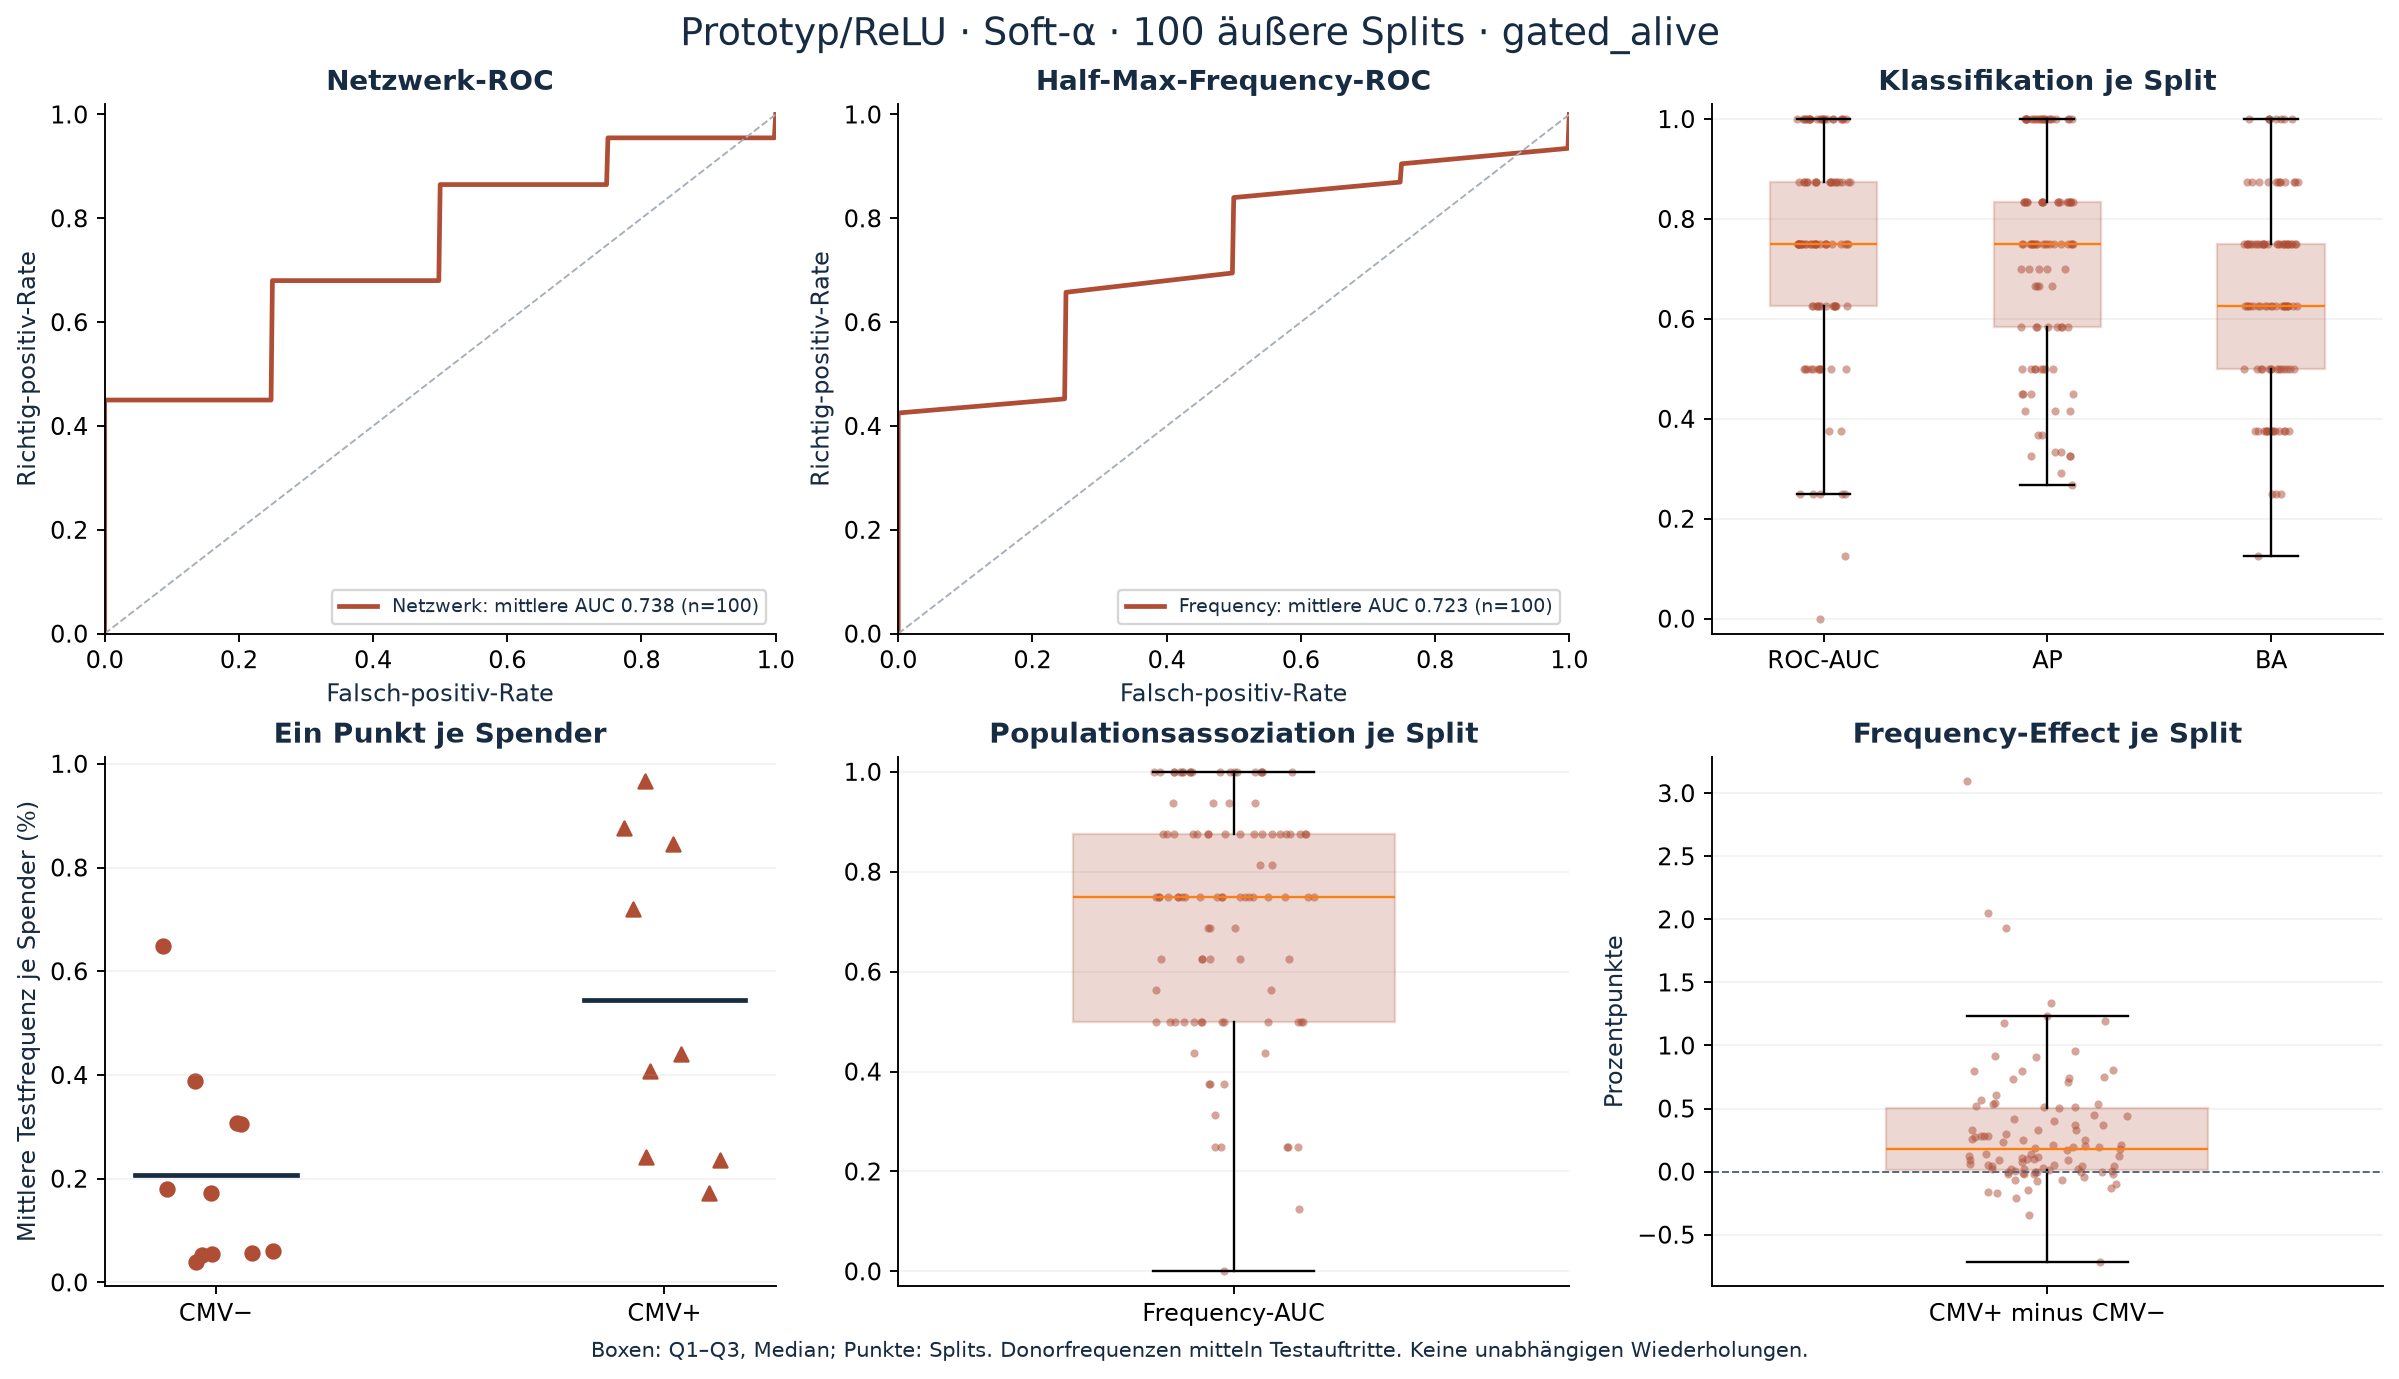

In [12]:
from src.task6_comparison import plot_model_results
from IPython.display import Image

plot_path = plot_model_results(modified_predictions, modified_responses, TABLES / "plots/prototype_soft", "prototype_soft", donor_splits)
display(Image(filename=str(plot_path)))
